                       Name Platform  Year_of_Release         Genre Publisher  \
0                Wii Sports      Wii           2006.0        Sports  Nintendo   
1         Super Mario Bros.      NES           1985.0      Platform  Nintendo   
2            Mario Kart Wii      Wii           2008.0        Racing  Nintendo   
3         Wii Sports Resort      Wii           2009.0        Sports  Nintendo   
4  Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing  Nintendo   

   NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  Critic_Score  \
0     41.36     28.96      3.77         8.45         82.53          76.0   
1     29.08      3.58      6.81         0.77         40.24           NaN   
2     15.68     12.76      3.79         3.29         35.52          82.0   
3     15.61     10.93      3.28         2.95         32.77          80.0   
4     11.27      8.89     10.22         1.00         31.37           NaN   

   Critic_Count User_Score  User_Count Developer Rating 

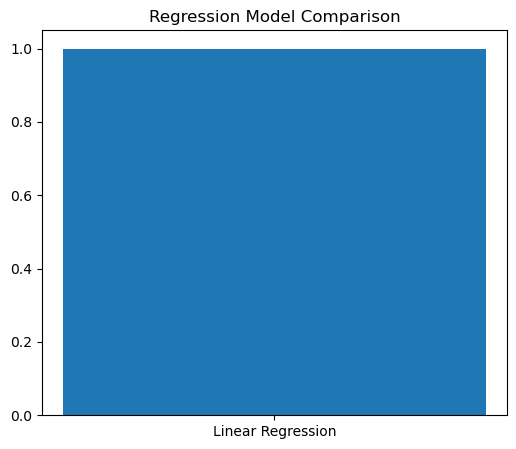

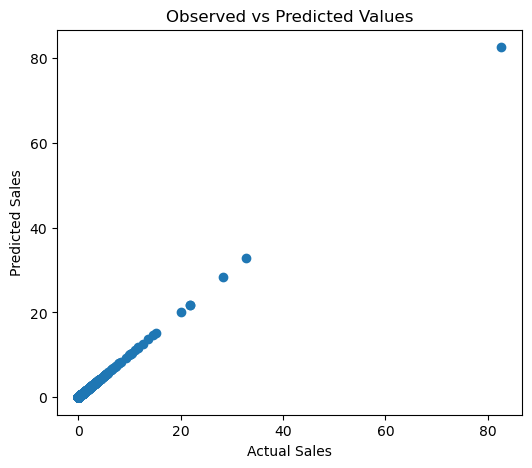

CLUSTER ANALYSIS


/lib/python3.13/site-packages/threadpoolctl.py:1129: UserWarning: Unable to import LDSO from pyodide_js._module. This should never happen.
  warnings.warn(


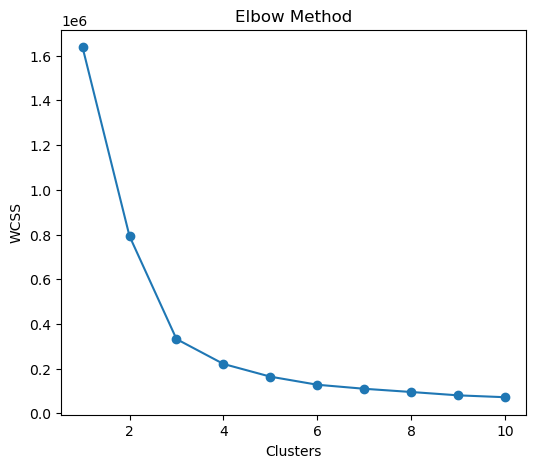

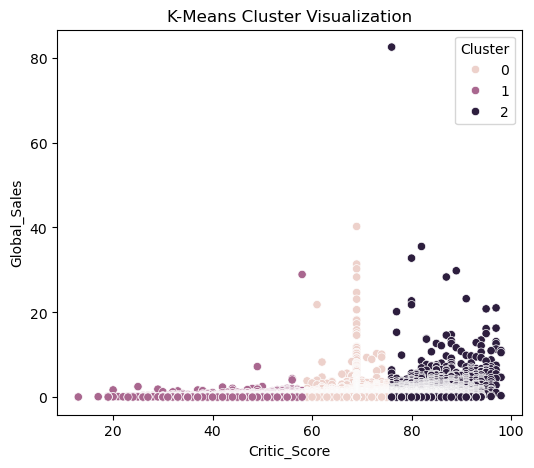

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score

# load dataset
df = pd.read_csv("Video_Games_Sales_as_at_22_Dec_2016.csv")

print(df.head())
print(df.shape)

# remove duplicates
df.drop_duplicates(inplace=True)

# convert user score to numeric
df["User_Score"] = pd.to_numeric(df["User_Score"], errors="coerce")

# fill missing values in numeric columns
num_cols = ["Critic_Score","User_Score","Year_of_Release","Global_Sales"]

for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

# fill missing values in text columns
cat_cols = ["Genre","Platform","Rating"]

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# convert text columns into numbers
df_encoded = pd.get_dummies(df, columns=["Genre","Platform"], drop_first=True)

# ---------------- REGRESSION ----------------
print("REGRESSION MODELS")

X = df_encoded.select_dtypes(include=[np.number]).drop("Global_Sales", axis=1)
y = df_encoded["Global_Sales"]

X = X.fillna(X.mean())
y = y.fillna(y.mean())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train, y_train)

pred = lr.predict(X_test)

print("R2 Score:", r2_score(y_test, pred))

# bar chart
plt.figure(figsize=(6,5))
plt.bar(["Linear Regression"], [r2_score(y_test, pred)])
plt.title("Regression Model Comparison")
plt.show()

# scatter plot
plt.figure(figsize=(6,5))
plt.scatter(y_test, pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Observed vs Predicted Values")
plt.show()

# ---------------- CLUSTERING ----------------
print("CLUSTER ANALYSIS")

cluster_data = df_encoded[["Critic_Score","User_Score","Global_Sales"]]

cluster_data = cluster_data.fillna(cluster_data.mean())

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(cluster_data)
    wcss.append(kmeans.inertia_)

# elbow chart
plt.figure(figsize=(6,5))
plt.plot(range(1,11), wcss, marker="o")
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

# kmeans clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(cluster_data)

df_encoded["Cluster"] = clusters

# cluster scatter plot
plt.figure(figsize=(6,5))
sns.scatterplot(
    x=df_encoded["Critic_Score"],
    y=df_encoded["Global_Sales"],
    hue=df_encoded["Cluster"]
)

plt.title("K-Means Cluster Visualization")
plt.show()

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn

mambajs 0.19.13

Process pip requirements ...



Cannot install 'pandas' from PyPI because it is a binary built package that is not compatible with WASM environments. To resolve this issue, you can: 1) Try to install it from emscripten-forge instead: "!mamba install pandas" 2) If that doesn't work, it's probably that the package was not made WASM-compatible on emscripten-forge. You can either request or contribute a new recipe for that package in https://github.com/emscripten-forge/recipes 

In [ ]:
!mamba install pandas numpy matplotlib seaborn scikit-learn -y

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, scikit-learn, -y
Channels: emscripten-forge, conda-forge

Solving environment...


Cannot solve the request because of: No candidates were found for -y *.


In [4]:
!mamba install pandas numpy matplotlib seaborn scikit-learn

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, scikit-learn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 0.665 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ brotli-python                 1.2.0                         py313h33caa6c_0               emscripten-forge              
+ certifi                       2026.4.22                     pyhd8ed1ab_0                  conda-forge                   
+ charset-normalizer            3.4.7                         pyhd8ed1ab_0                  conda-forge                   
+ idna                          3.13                          pyhcf101f3_0                  conda-forge                   
+ joblib                        1.5.3    

In [2]:
!mamba install pandas numpy matplotlib seaborn scikit-learn

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, scikit-learn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 2.834 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ brotli-python                 1.2.0                         py313h33caa6c_0               emscripten-forge              
+ certifi                       2026.4.22                     pyhd8ed1ab_0                  conda-forge                   
+ charset-normalizer            3.4.7                         pyhd8ed1ab_0                  conda-forge                   
+ idna                          3.13                          pyhcf101f3_0                  conda-forge                   
+ joblib                        1.5.3    